# Recommendation Systems for Amazon Books

In [ ]:
!pip install -q scikit-surprise
!pip install numpy==1.24.4

## ***Overview:***

In this project, I will build recommender systems using different approaches.

I will be using the Amazon Review data:
https://nijianmo.github.io/amazon/index.html

Note this is a fairly large dataset. I will use the Book review from `"Small" subsets for experimentation` and use `ratings only(51,311,621 ratings)` dataset.

Due to the large dataset size, the code will be written with computational cost (both spatial and temporal) in mind.

- In general when you want to discard a python object when you no longer need it (automatical garbage collection will do it also but probably not in time):
```python
del some_data_frame
```

- In general a vectorized function runs much efficiently than `for loop`:
```python
    # slow:
    total =0
    for data in dataframe["grades"]:
        if data>5: total+=data
    print(total)
```
```python
    # much faster:
    print(
        dataframe["grades"][dataframe["grades"]>5].sum()
)
```

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

## Step 1: Data Ingestion

First, download the dataset. If working on this dataset for an extended period, mounting Google Drive makes it easier to save and load data across sessions. This dataset contains book reviews from Amazon, with the following columns:

*  User ID
*  Book ID
*  Rating (1 to 5)
*  Date they gave the ratings (unix timestamp, converted to datetime objects.)

Because of the large data size, we'll create a smaller dataset using the first 10,000 lines for initial experimentation to ensure the code works properly before scaling up to the full dataset.

In [ ]:
drive.mount('/content/drive')
!cp /content/drive/MyDrive/Datasets/Books.csv /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Greate a smaller data set.

In [ ]:
!tail -n 10000 Books.csv > books10m.csv

Read data set and check it.

In [ ]:
books10m = pd.read_csv('books10m.csv', header = None)

In [ ]:
# Change column names
books10m.columns = ["User_ID", "Book_ID", "Rating", "Timestamp"]

# Convert the timestamp
books10m["Timestamp"] = pd.to_datetime(books10m["Timestamp"], unit='s')

books10m.head()

,User_ID,Book_ID,Rating,Timestamp
0,B01FVXST80,A3AKHOL7HXJICR,1.0,2017-08-28
1,B01FW12SK6,A30EPXF2OWMEDV,5.0,2016-10-03
2,B01FW12SK6,AMVPJE06EER32,5.0,2016-08-25
3,B01FW1PMVS,A3RYNK6RAGF7KD,5.0,2018-02-28
4,B01FW1PMVS,A2FRZVXHOQ980F,5.0,2017-01-29


## Step 2: Reservoir Sampling

To handle the massive dataset effectively, we'll implement a `Reservoir_Sampling` function to sample a representative subset of the data.

It takes the input file name `infile_name` and uniformly samples `k` lines. This approach mimics reading streaming data line by line, ensuring that at any moment, for the `n` data points received so far, we keep `k` points uniformly sampled from the infinite stream.

Algorithm logic:
- if `n<=k` we keep all incoming data points from the stream in a list `KEEP`;
- when a new data point that is $n^{th}$ comes, if n>k, roll a dice that gives the new data point a probability of **k/n**  to be appended to `KEEP`;
    - if the $n^{th}$ new data point is to be added to `KEEP` and if doing so would cause `len(KEEP)==k+1`, we roll another dice to randomly pick a point from `KEEP` (before appending) to throw away, each data point in `KEEP` has equal probability to be discarded.

This project samples k=10,000,000 (10 million) lines to create `books10m.csv`.

In [ ]:
def Reservoir_Sampling(infile_name, outfile_name, k):
    KEEP = [0] * k
    n = 0

    with open(infile_name, 'r') as file:
        for line in file:
            n += 1
            if n <= k:
                KEEP[n-1] = line
            else:
                temp = random.randint(1, n)
                if temp <= k:
                    KEEP[temp-1] = line

    with open(outfile_name, 'w') as file:
        file.writelines(KEEP)

### Execute Sampling

In [ ]:
Reservoir_Sampling('Books.csv', 'books10m.csv', 10000000)

## Step 3: Exploratory Data Analysis (EDA)

Let's explore the data with appropriate plots and tables: total counts, value distributions of user-item interactions, and time dependency of the statistics to gain good insights into the data.

In [ ]:
books = pd.read_csv('books10m.csv', header = None)

In [ ]:
# Change column names
books.columns = ["User_ID", "Book_ID", "Rating", "Timestamp"]

# Convert the timestamp
books["Timestamp"] = pd.to_datetime(books["Timestamp"], unit='s')

books.head()

,User_ID,Book_ID,Rating,Timestamp
0,0974026530,A3SDZQL0F5YVH2,4.0,2009-05-07
1,0882666118,A2W7WH9V5OKUA9,4.0,2010-06-08
2,0001713353,A1YRBRK2XM5D5,5.0,2004-04-04
3,1462111181,A3VC3ENISEK35R,5.0,2015-01-20
4,0001713353,A2ZB06582NXCIV,5.0,2016-10-03


In [ ]:
# Describe the data set
books.describe()

,Rating,Timestamp
count,1.000000e+07,10000000
mean,4.392968e+00,2014-04-29 11:16:26.719678976
min,0.000000e+00,1996-11-26 00:00:00
25%,4.000000e+00,2013-05-19 00:00:00
50%,5.000000e+00,2015-02-11 00:00:00
75%,5.000000e+00,2016-08-26 00:00:00
max,5.000000e+00,2018-09-30 00:00:00
std,1.045616e+00,NaN


We can see the mean rating is quite high. And std is around 1.

In [ ]:
# Top 5 users
books['User_ID'].value_counts().head(5)

,count
User_ID,
038568231X,11379
0007420412,8730
0297859382,8719
0141353678,7343
0312577222,7019


In [ ]:
# Top 5 books
books['Book_ID'].value_counts().head(5)

,count
Book_ID,
A2OJW07GQRNJUT,1892
A2F6N60Z96CAJI,1779
A328S9RN3U5M68,1373
AHUT55E980RDR,1149
A1X8VZWTOG8IS6,898


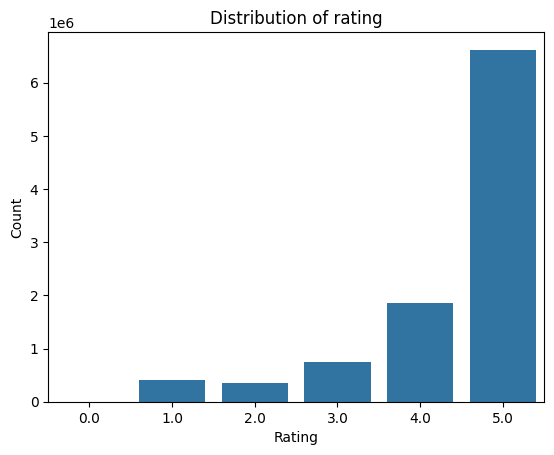

In [ ]:
# Distribution of rating
plot_3 = books['Rating'].value_counts()

sns.barplot(plot_3)
plt.title('Distribution of rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

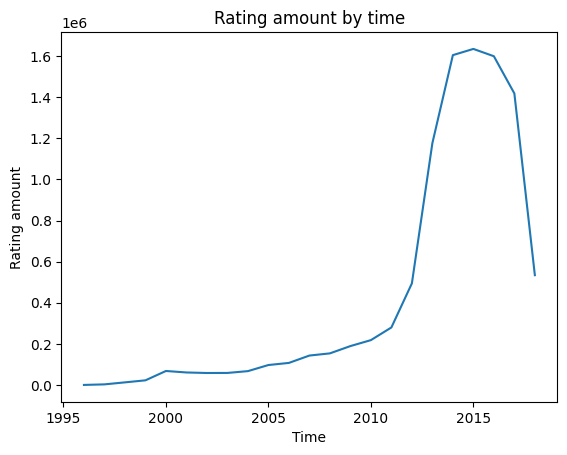

In [ ]:
# Rating by time
plot_4 = books['Timestamp'].dt.year.value_counts()

sns.lineplot(plot_4)
plt.title('Rating amount by time')
plt.xlabel('Time')
plt.ylabel('Rating amount')
plt.show()

## Step 4: Data Trimming

Since the dataset is highly sparse, we need to trim down the size of the data by:

- Removing data before '2010-01-01 00:00:00' to focus on more recent data.
- Removing books that received less than or equal to 2 user ratings.
- Removing users that reviewed less than or equal to `m` books, where m is 80% quantile of user ratings count (keeping only the top 20% most active users).

These steps are combined into a function `trim(book_data_frame)`.

In [ ]:
books['Timestamp'].min()

Timestamp('1996-11-26 00:00:00')

In [ ]:
def trim(book_data_frame):
    # Remove data before a certain point in time
    book_data_frame = book_data_frame[book_data_frame['Timestamp'] >= '2010-01-01 00:00:00']

    # Find books with more than 2 ratings
    book_count = book_data_frame['Book_ID'].value_counts()
    book_count = book_count[book_count > 2]

    # Find top active users
    user_count = book_data_frame['User_ID'].value_counts()
    user_count = user_count[user_count > user_count.quantile(0.8)]

    book_data_frame = book_data_frame[book_data_frame['Book_ID'].isin(book_count.index) | book_data_frame['User_ID'].isin(user_count.index)]

    return book_data_frame

Before triming

In [ ]:
print("Count of book\n", books['Book_ID'].value_counts().describe())
print("\nCount of user\n", books['User_ID'].value_counts().describe())
print("\nShape of data frame\n", books.shape)

Count of book
 count    5.342903e+06
mean     1.871642e+00
std      4.819977e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.892000e+03
Name: count, dtype: float64

Count of user
 count    1.586943e+06
mean     6.301424e+00
std      3.801434e+01
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      1.137900e+04
Name: count, dtype: float64

Shape of data frame
 (10000000, 4)


After triming

In [ ]:
trim_books = trim(books)
print("Count of book\n", trim_books['Book_ID'].value_counts().describe())
print("\nCount of user\n", trim_books['User_ID'].value_counts().describe())
print("\nShape of data frame\n", trim_books.shape)

Count of book
 count    3.838194e+06
mean     2.011379e+00
std      4.845255e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.869000e+03
Name: count, dtype: float64

Count of user
 count    840590.000000
mean          9.184099
std          49.917568
min           1.000000
25%           1.000000
50%           2.000000
75%           7.000000
max       11379.000000
Name: count, dtype: float64

Shape of data frame
 (7720062, 4)


In [ ]:
# Resample
resample_books = trim_books.sample(frac=0.3)

# Trim again
resample_books = trim(resample_books)

resample_books.shape

(1870595, 4)

## Step 5: Model Fitting with Surprise Library

Here we prepare the data for the `surprise` library and fit the data with latent factor decomposition (SVD). This factorizes the user-item matrix into latent factor matrices P and Q. The model is evaluated using 3-fold cross-validation, printing the RMS error for each run.

We will experiment with different hyperparameter configurations to compare RMSE and running time.

In [ ]:
from surprise import SVD
from surprise import Dataset
from surprise.model_selection import cross_validate
from surprise import Reader
from surprise import accuracy
from surprise.model_selection import KFold

In [ ]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(trim_books[["User_ID", "Book_ID", "Rating"]], reader)

#### Run code chunk below as is after data is loaded.

In [ ]:
# define a cross-validation iterator
kf = KFold(n_splits=3)

algo = SVD()

for trainset, testset in kf.split(data):

    # train and test algorithm.
    algo.fit(trainset)
    predictions = algo.test(testset)

    # Compute and print Root Mean Squared Error
    accuracy.rmse(predictions, verbose=True)

RMSE: 0.9487
RMSE: 0.9493
RMSE: 0.9487


Output example (yours may look differently):
```
RMSE: 0.8948
RMSE: 0.8936
RMSE: 0.8968
```

#### Copy code chunk above and use different parameters for `SVD` call, then rerun.

In [ ]:
# define a cross-validation iterator
kf = KFold(n_splits=3)

algo = SVD(n_factors=50, lr_all=.01, reg_all=.01)

for trainset, testset in kf.split(data):

    # train and test algorithm.
    algo.fit(trainset)
    predictions = algo.test(testset)

    # Compute and print Root Mean Squared Error
    accuracy.rmse(predictions, verbose=True)

RMSE: 0.9478
RMSE: 0.9471
RMSE: 0.9484


In [ ]:
# define a cross-validation iterator
kf = KFold(n_splits=3)

algo = SVD(n_factors=150, lr_all=.1, reg_all=.1)

for trainset, testset in kf.split(data):

    # train and test algorithm.
    algo.fit(trainset)
    predictions = algo.test(testset)

    # Compute and print Root Mean Squared Error
    accuracy.rmse(predictions, verbose=True)

RMSE: 0.9499
RMSE: 0.9489
RMSE: 0.9494


#### Model Observations

Model 1:
- Running time: 8 min
- RMSE: 0.9487, 0.9493, 0.9487

Model 2:
- Running time: 8 min
- RMSE: 0.9478, 0.9471, 0.9484

Model 3:
- Running time: 11 min
- RMSE: 0.9499, 0.9489, 0.9494

Explain:

Larger n_factors increases training time.  
Larger lr_all makes model unstable.  
Larger reg_all controls overfit better.

## Step 6: Generating Recommendations

Using the previously trained SVD model (n_factors=150), we can select a user from the dataset and predict their ratings for unread books. Here we extract the top 10 recommended books that they are predicted to rate the highest.

In [ ]:
# Pick one user from the trainset
user_id = trainset.to_raw_uid(9)

# Get all book ids
all_book_inner_ids = trainset.all_items()
all_book_raw_ids = [trainset.to_raw_iid(i) for i in all_book_inner_ids]

# Get rated books
rated_inner_ids = [i for (i, _) in trainset.ur[trainset.to_inner_uid(user_id)]]
rated_raw_ids = set([trainset.to_raw_iid(i) for i in rated_inner_ids])

# Remove rated books
unrated_raw_ids = [iid for iid in all_book_raw_ids if iid not in rated_raw_ids]

# Predict all unrated books
predictions = [algo.predict(user_id, iid) for iid in unrated_raw_ids]

top_10 = sorted(predictions, key=lambda x: x.est, reverse=True)[:10]

for i in top_10:
    print(f"Item: {i.iid}, Predicted Rating: {i.est:.2f}")

Item: A2EYE8VS70TATH, Predicted Rating: 5.00
Item: A1RAJ5PHN9QYWT, Predicted Rating: 5.00
Item: ABYTURFN110AD, Predicted Rating: 5.00
Item: A3CC0LZ9XY4I7Q, Predicted Rating: 5.00
Item: A1GGM046879U03, Predicted Rating: 5.00
Item: A1D56ETVO4R1EQ, Predicted Rating: 5.00
Item: A11YCCTA2943JV, Predicted Rating: 5.00
Item: ABW67YKRUA1XZ, Predicted Rating: 5.00
Item: A1EEHLQQ5YOLXL, Predicted Rating: 5.00
Item: A2WIR0VWXF8D6Y, Predicted Rating: 5.00


## Step 7: Building SVD from Scratch

To better understand matrix factorization, we can build SVD from scratch using Stochastic Gradient Descent (SGD) without relying on the `surprise` library.

To avoid crashing due to memory limits, we'll further resample the data and utilize sparse matrix representations where necessary.

In [ ]:
# Resample
resample_books_2 = resample_books.sample(frac=0.1)

# Trim again
resample_books_2 = trim(resample_books_2)

resample_books_2.shape

(113796, 4)

In [ ]:
reader = Reader(rating_scale=(1, 5))
data_2 = Dataset.load_from_df(resample_books_2[["User_ID", "Book_ID", "Rating"]], reader)

In [ ]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data_2, test_size=.25)

n_users = trainset.n_users
n_items = trainset.n_items

R = np.zeros((n_users, n_items))
for u_inner in range(n_users):
    for i_inner, rating in trainset.ur[u_inner]:
        R[u_inner, i_inner] = rating

In [ ]:
class MF():

    def __init__(self, R, K, alpha, beta, iterations):
        """
        Perform matrix factorization to predict empty
        entries in a matrix.

        Arguments
        - R (ndarray)   : user-item rating matrix
        - K (int)       : number of latent dimensions
        - alpha (float) : learning rate
        - beta (float)  : regularization parameter
        """

        self.R = R
        self.num_users, self.num_items = R.shape
        self.K = K
        self.alpha = alpha
        self.beta = beta
        self.iterations = iterations

    def train(self):
        # Initialize user and item latent feature matrice
        self.P = np.random.normal(scale=1./self.K, size=(self.num_users, self.K))
        self.Q = np.random.normal(scale=1./self.K, size=(self.num_items, self.K))

        # Initialize the biases
        self.b_u = np.zeros(self.num_users)
        self.b_i = np.zeros(self.num_items)
        self.b = np.mean(self.R[np.where(self.R != 0)])

        # Create a list of training samples
        self.samples = [
            (i, j, self.R[i, j])
            for i in range(self.num_users)
            for j in range(self.num_items)
            if self.R[i, j] > 0
        ]

        # Perform stochastic gradient descent for number of iterations
        training_process = []
        for i in range(self.iterations):
            np.random.shuffle(self.samples)
            self.sgd()
            mse = self.mse()
            training_process.append((i, mse))
            if (i+1) % 10 == 0:
                print("Iteration: %d ; error = %.4f" % (i+1, mse))

        return training_process

    def mse(self):
        """
        A function to compute the total mean square error
        """
        xs, ys = self.R.nonzero()
        predicted = self.full_matrix()
        error = 0
        for x, y in zip(xs, ys):
            error += pow(self.R[x, y] - predicted[x, y], 2)
        return np.sqrt(error)

    def sgd(self):
        """
        Perform stochastic graident descent
        """
        for i, j, r in self.samples:
            # Computer prediction and error
            prediction = self.get_rating(i, j)
            e = (r - prediction)

            # Update biases
            self.b_u[i] += self.alpha * (e - self.beta * self.b_u[i])
            self.b_i[j] += self.alpha * (e - self.beta * self.b_i[j])

            # Update user and item latent feature matrices
            self.P[i, :] += self.alpha * (e * self.Q[j, :] - self.beta * self.P[i,:])
            self.Q[j, :] += self.alpha * (e * self.P[i, :] - self.beta * self.Q[j,:])

    def get_rating(self, i, j):
        """
        Get the predicted rating of user i and item j
        """
        prediction = self.b + self.b_u[i] + self.b_i[j] + self.P[i, :].dot(self.Q[j, :].T)
        return prediction

    def full_matrix(self):
        """
        Computer the full matrix using the resultant biases, P and Q
        """
        return self.b + self.b_u[:,np.newaxis] + self.b_i[np.newaxis:,] + self.P.dot(self.Q.T)

In [ ]:
mf = MF(R, K=2, alpha=0.1, beta=0.01, iterations=20)
mf.train()

In [ ]:
y_true = []
y_pred = []

for uid, iid, true_r in testset:
    if trainset.knows_user(uid) and trainset.knows_item(iid):
        u_inner = trainset.to_inner_uid(uid)
        i_inner = trainset.to_inner_iid(iid)
        pred_r = mf.get_rating(u_inner, i_inner)
        y_true.append(true_r)
        y_pred.append(pred_r)

rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"Test RMSE: {rmse:.4f}")

# Conclusion

This project explored handling large-scale sparse datasets, from data ingestion and reservoir sampling to cleaning and exploratory analysis. We successfully utilized Matrix Factorization via Singular Value Decomposition (SVD) to build a recommendation engine using the `scikit-surprise` library and subsequently reconstructed the foundational algorithm from scratch using Stochastic Gradient Descent.